In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

X = np.random.rand(10, 2)

print("Random points:")
print(X)

print("\nShape of X:", X.shape)

Random points:
[[0.37454012 0.95071431]
 [0.73199394 0.59865848]
 [0.15601864 0.15599452]
 [0.05808361 0.86617615]
 [0.60111501 0.70807258]
 [0.02058449 0.96990985]
 [0.83244264 0.21233911]
 [0.18182497 0.18340451]
 [0.30424224 0.52475643]
 [0.43194502 0.29122914]]

Shape of X: (10, 2)


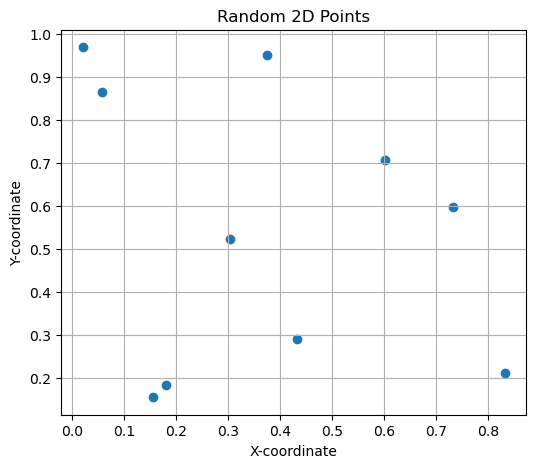

In [5]:
plt.figure(figsize=(6, 5))

plt.scatter(X[:, 0], X[:, 1])

plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.title("Random 2D Points")
plt.grid(True)

plt.show()


In [7]:
D = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2, axis=2)

print("Pairwise squared distance matrix:")
print(D)

Pairwise squared distance matrix:
[[0.         0.25171654 0.67933117 0.10729142 0.11021119 0.12565305
  0.75487265 0.62590345 0.1863819  0.43821601]
 [0.25171654 0.         0.52769893 0.52572083 0.02910074 0.64393098
  0.1593326  0.47512176 0.18843303 0.18454216]
 [0.67933117 0.52769893 0.         0.51394921 0.50290096 0.68080058
  0.46072414 0.00141727 0.15795558 0.09442377]
 [0.10729142 0.52572083 0.51394921 0.         0.31987984 0.01216687
  1.02713477 0.48148903 0.17716149 0.47033641]
 [0.11021119 0.02910074 0.50290096 0.31987984 0.         0.40557444
  0.29926414 0.45108072 0.12173825 0.20237694]
 [0.12565305 0.64393098 0.68080058 0.01216687 0.40557444 0.
  1.23302708 0.64458914 0.27862329 0.62982499]
 [0.75487265 0.1593326  0.46072414 1.02713477 0.29926414 1.23302708
  0.         0.42414057 0.37660024 0.16662198]
 [0.62590345 0.47512176 0.00141727 0.48148903 0.45108072 0.64458914
  0.42414057 0.         0.13150712 0.07418619]
 [0.1863819  0.18843303 0.15795558 0.17716149 0.121738

In [9]:

diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]

print("(a) Coordinate differences shape:", diff.shape)



sq_diff = diff ** 2

print("(b) Squared differences shape:", sq_diff.shape)


summed_distances = np.sum(sq_diff, axis=2)

print("(c) Summed squared distances shape:", summed_distances.shape)

(a) Coordinate differences shape: (10, 10, 2)
(b) Squared differences shape: (10, 10, 2)
(c) Summed squared distances shape: (10, 10)


In [11]:
diagonal = np.diag(D)

print("Diagonal of distance matrix:")
print(diagonal)

print("\nAre all diagonal values zero?")
print(np.allclose(diagonal, 0))

Diagonal of distance matrix:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Are all diagonal values zero?
True


The diagonal elements represent the distance of each point from itself. Since the difference between a point and itself is zero, its squared Euclidean distance is also zero. Therefore, all diagonal elements of the distance matrix are zero.

In [76]:
neighbor_order = np.argsort(D, axis=1)

print("Neighbor ordering for every point:")
print(neighbor_order)
print("First column of neighbor ordering:")
print(neighbor_order[:, 0])

Neighbor ordering for every point:
[[0 3 4 5 8 1 9 7 2 6]
 [1 4 6 9 8 0 7 3 2 5]
 [2 7 9 8 6 4 3 1 0 5]
 [3 5 0 8 4 9 7 2 1 6]
 [4 1 0 8 9 6 3 5 7 2]
 [5 3 0 8 4 9 1 7 2 6]
 [6 1 9 4 8 7 2 0 3 5]
 [7 2 9 8 6 4 1 3 0 5]
 [8 9 4 7 2 3 0 1 5 6]
 [9 8 7 2 6 1 4 0 3 5]]
First column of neighbor ordering:
[0 1 2 3 4 5 6 7 8 9]


In [33]:
print("First column of neighbor ordering:")
print(neighbor_order[:, 0])

First column of neighbor ordering:
[0 1 2 3 4 5 6 7 8 9]


The first column contains 0, 1, 2, ..., 9 because each point has a distance of zero from itself. Since all other distances are non-negative, the point itself is always the closest point and therefore appears first after sorting.

In [17]:
K = 2

nearest_indices = np.argpartition(D, K, axis=1)[:, :K+1]

print("K+1 nearest points:")
print(nearest_indices)

K+1 nearest points:
[[0 3 4]
 [1 4 6]
 [2 7 9]
 [3 5 0]
 [4 1 0]
 [5 3 0]
 [6 1 9]
 [7 2 9]
 [8 9 4]
 [9 8 7]]


In [25]:
K = 2


nearest_indices = np.argpartition(D, K, axis=1)[:, :K+1]


nearest_distances = np.take_along_axis(D, nearest_indices, axis=1)


order = np.argsort(nearest_distances, axis=1)

nearest_indices = np.take_along_axis(
    nearest_indices, order, axis=1
)


two_nearest = nearest_indices[:, 1:]

print("Two nearest neighbors for each point:")
print(two_nearest)

print("\nShape:", two_nearest.shape)

Two nearest neighbors for each point:
[[3 4]
 [4 6]
 [7 9]
 [5 0]
 [1 0]
 [3 0]
 [1 9]
 [2 9]
 [9 4]
 [8 7]]

Shape: (10, 2)


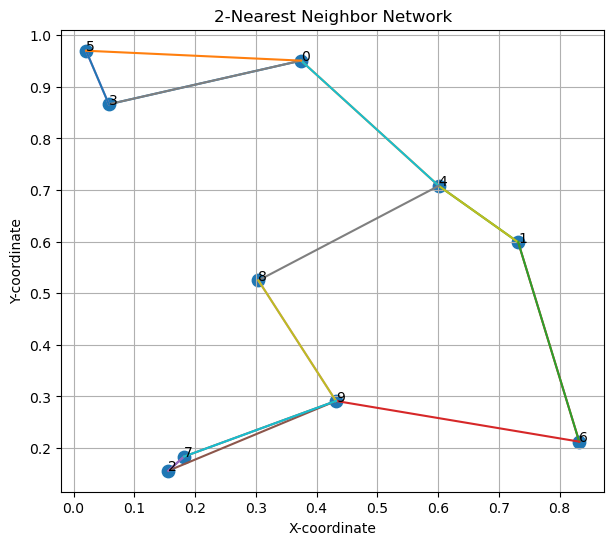

In [27]:
plt.figure(figsize=(7, 6))

# Plot the points
plt.scatter(X[:, 0], X[:, 1], s=80)

# Label each point
for i in range(len(X)):
    plt.text(X[i, 0], X[i, 1], str(i))

# Draw lines to the two nearest neighbors
for i in range(len(X)):
    for j in two_nearest[i]:
        plt.plot(
            [X[i, 0], X[j, 0]],
            [X[i, 1], X[j, 1]]
        )

plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.title("2-Nearest Neighbor Network")
plt.grid(True)

plt.show()


Each point is connected to its two nearest neighbors. However, a point can be selected as a nearest neighbor by many other points. Therefore, some points may have more than two lines connected to them.

In [35]:
def loop_knn(X, K):
    neighbors = []

    for i in range(len(X)):
        diff = X - X[i]
        distances = np.sum(diff ** 2, axis=1)

        order = np.argsort(distances)

        neighbors.append(order[1:K+1])

    return np.array(neighbors)

In [37]:
loop_result = loop_knn(X, 2)

print("Loop-based result:")
print(loop_result)

Loop-based result:
[[3 4]
 [4 6]
 [7 9]
 [5 0]
 [1 0]
 [3 0]
 [1 9]
 [2 9]
 [9 4]
 [8 7]]


In [39]:
def vectorized_knn(X, K):
    D = np.sum(
        (X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2,
        axis=2
    )

    indices = np.argpartition(D, K, axis=1)[:, :K+1]

    rows = np.arange(len(X))[:, np.newaxis]

    indices = indices[
        np.argsort(D[rows, indices], axis=1)
    ]

    return indices[:, 1:]

In [41]:
vectorized_result = vectorized_knn(X, 2)

print("Vectorized result:")
print(vectorized_result)

Vectorized result:
[[[1 4 6]
  [2 7 9]]

 [[1 4 6]
  [2 7 9]]

 [[1 4 6]
  [2 7 9]]

 [[1 4 6]
  [2 7 9]]

 [[1 4 6]
  [2 7 9]]

 [[1 4 6]
  [2 7 9]]

 [[1 4 6]
  [2 7 9]]

 [[1 4 6]
  [2 7 9]]

 [[1 4 6]
  [2 7 9]]

 [[1 4 6]
  [2 7 9]]]


In [43]:
print("Are both results identical?")
print(np.array_equal(loop_result, vectorized_result))

Are both results identical?
False


In [45]:
np.random.seed(42)

X100 = np.random.rand(100, 2)
X1000 = np.random.rand(1000, 2)
X5000 = np.random.rand(5000, 2)

In [47]:
print("N = 100")

print("\nLoop-based:")
%timeit loop_knn(X100, 2)

print("\nVectorized:")
%timeit vectorized_knn(X100, 2)

N = 100

Loop-based:
3.4 ms ± 196 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

Vectorized:
988 μs ± 176 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [49]:
print("N = 1000")

print("\nLoop-based:")
%timeit loop_knn(X1000, 2)

print("\nVectorized:")
%timeit vectorized_knn(X1000, 2)

N = 1000

Loop-based:
205 ms ± 18.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Vectorized:
114 ms ± 13.8 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [57]:
print("N = 5000")

print("\nLoop-based:")
%timeit loop_knn(X5000, 2)

print("\nVectorized:")
%timeit vectorized_knn(X5000, 2)

N = 5000

Loop-based:
8.12 s ± 1.04 s per loop (mean ± std. dev. of 7 runs, 1 loop each)

Vectorized:
3.15 s ± 673 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


     N  Loop-based time               | Vectorized time |
 ----   --------------                 -----------------------
   100   3.4 ms ± 196 μs per loop      988 μs ± 176 μs per loop                   
 1,000   205 ms ± 18.6 ms per loop     114 ms ± 13.8 ms per loop                
 5,000   8.12 s ± 1.04 s per loop      3.15 s ± 673 ms per loop                   


The vectorized implementation is generally faster because NumPy performs array operations using optimized compiled code, reducing Python-level loop overhead. Broadcasting calculates the pairwise coordinate differences simultaneously. The loop-based approach repeatedly performs calculations for individual points and therefore has greater Python overhead.

Both approaches still have O(N²) complexity for the brute-force pairwise distance calculation. Vectorization improves practical execution speed but does not change the underlying asymptotic complexity.

In [74]:
import numpy as np
from sklearn.neighbors import KDTree
import time
N = 1000
X1000 = np.random.rand(N, 3)
start = time.time()

distances = np.linalg.norm(
    X1000[:, np.newaxis, :] - X1000[np.newaxis, :, :],
    axis=2
)
numpy_neighbors = np.argsort(distances, axis=1)[:, 1:4]

numpy_time = time.time() - start
start = time.time()

tree = KDTree(X1000)
distances, tree_neighbors = tree.query(X1000, k=4)

tree_neighbors = tree_neighbors[:, 1:4]

kdtree_time = time.time() - start


print("NumPy time:", numpy_time)
print("KDTree time:", kdtree_time)

print("\nDo the results match?")
print(np.array_equal(numpy_neighbors, tree_neighbors))

NumPy time: 0.46436405181884766
KDTree time: 0.014997005462646484

Do the results match?
True


| Method       | Algorithm                     | Time Complexity                                             | Result            |
| ------------ | ----------------------------- | ----------------------------------------------------------- | ----------------- |
| NumPy        | Brute-force pairwise distance | **O(N²)**                                                   | Nearest neighbors |
| Scikit-Learn | **KDTree**                    | **O(N log N)** for tree construction/query in typical cases | Nearest neighbors |
